In [1]:
import sys

sys.path.append('../src/')
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import pysindy as ps
from libselection.utils import *
from libselection import *
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import matplotlib as mpl
import re

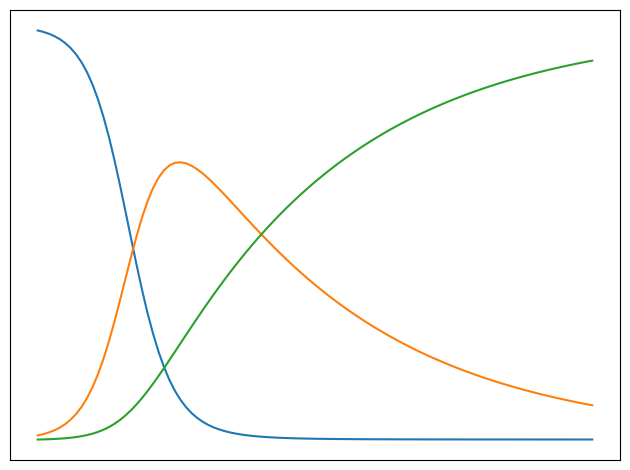

In [2]:
# Lorenz system parameters
beta = 0.3
gamma = 0.03

# Lorenz system equations
def SIR(t, state):
    S,I, R = state
    dxdt = -beta * S *I
    dydt = beta * S*I - gamma * I
    dzdt = gamma * I
    return [dxdt, dydt, dzdt]

# Time range for simulation
dt = 1
t = np.arange(0, 100 + 2*dt, dt)
# Initial condition
initial_state = np.array([0.99, 0.01, 0.])

# Solve the Lorenz system
SIR_data = solve_ivp(SIR, (t[0], t[-1]), initial_state, method='RK45', t_eval=t, atol=1e-10).y.T

# # Normalize the data for simplicity
# SIR_data = SIR_data / np.max(np.abs(SIR_data), axis=0)

# Plot the Lorenz attractor
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(SIR_data[:, 0])
ax.plot(SIR_data[:, 1])
ax.plot(SIR_data[:, 2])
# ax.set_xlabel("X")
# ax.set_ylabel("Y")
# ax.set_zlabel("Z")
# plt.title("Lorenz Attractor")

ax.set_xticks([])
ax.set_yticks([])
plt.tight_layout()



x_train = SIR_data
t_train = t
var_names = ['S', 'I', 'R']

library_gen = ps.PolynomialLibrary(degree=3) #+ ps.FourierLibrary(n_frequencies=2)
D = np.array(library_gen.fit_transform(x_train))
_, No_D = D.shape
name_tag = np.array(library_gen.get_feature_names(var_names))
x_dot = non_uniform_diff(x_train, t_train)


In [3]:
# Exhaustive filtering
plt.rcParams.update({'font.size': 14})
results = iter_scores_PI(D, x_dot, n_terms=1, stepwise=True, backwards=True, stepsize=1)


(19, 20)


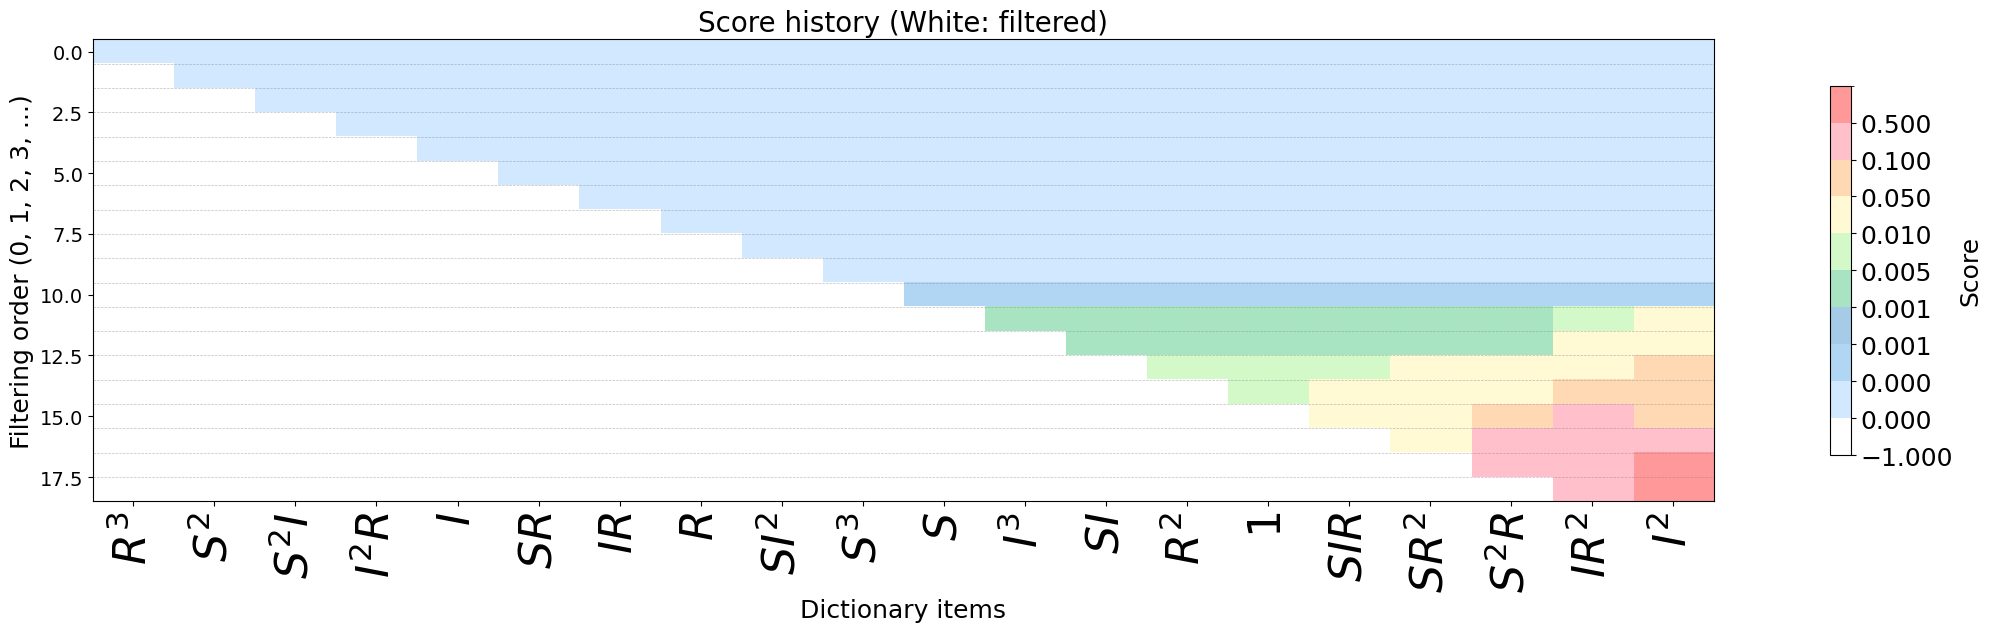

In [6]:
# Exhaustive filtering
plt.rcParams.update({'font.size': 14})
var = 2
best_comb, removed_order, history_values = iter_scores(D, x_dot[:,var:var+1], n_terms=1, stepwise=True, backwards=True, stepsize=1)

plot_filtering_history_sorted(removed_order, history_values, name_tag, save_path=None, diff_score=False, backwards = True,print_inside=False,save_eps=True)

(19, 20)


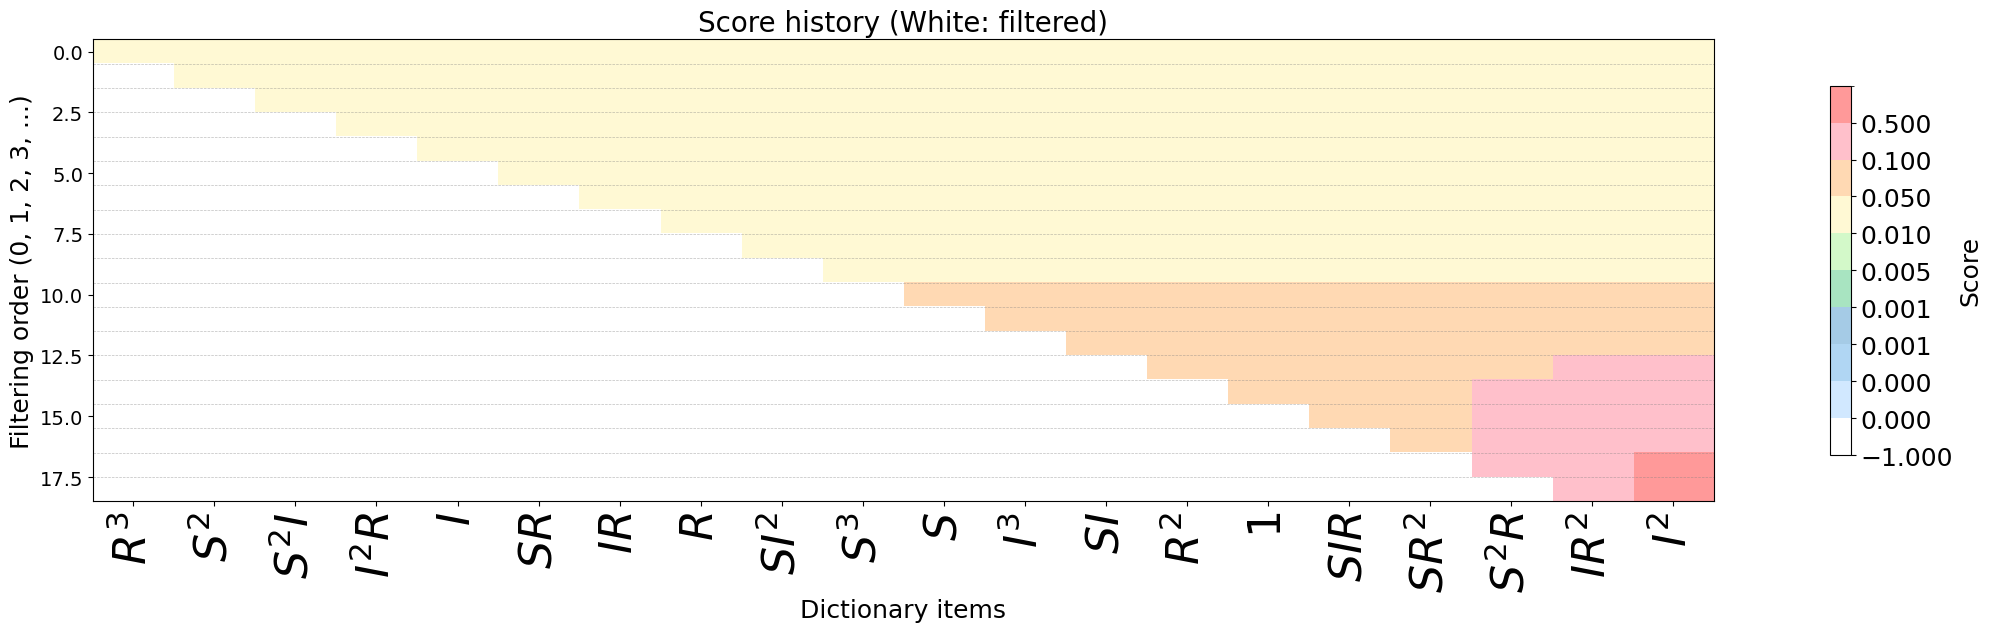

In [7]:
# var = 0
best_comb, removed_order, history_values = results[f'var_{var}']
plot_filtering_history_sorted(removed_order, history_values, name_tag, save_path=None, diff_score=False, backwards = True,print_inside=False,save_eps=True)